Tumor Sample: ['HCM-SANG-0280-C18-85A-01D-A79M-36']
Total variants: 143
Unique mutated genes: 140


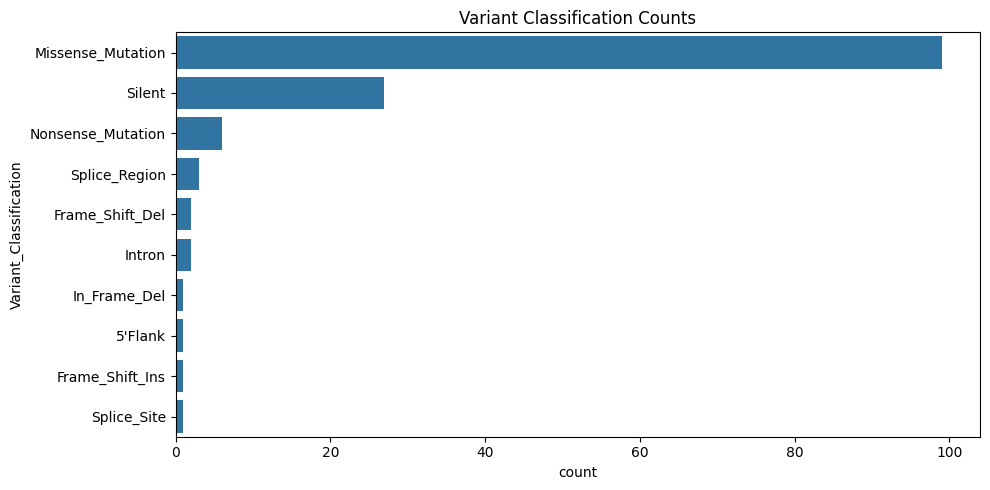

/tmp/ipykernel_321470/2944632812.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genes.values, y=top_genes.index, palette="viridis")


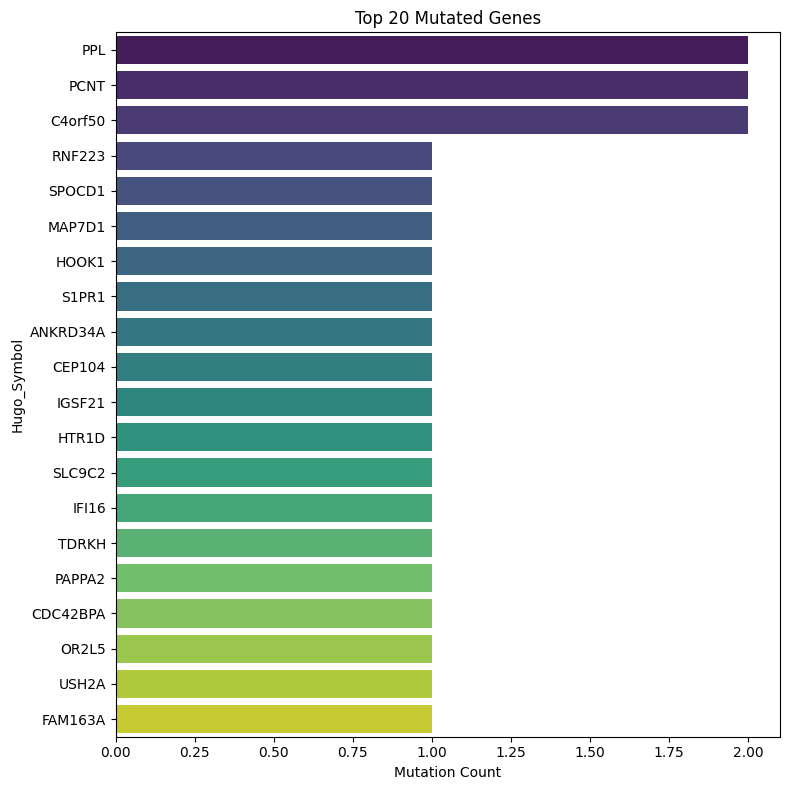

/tmp/ipykernel_321470/2944632812.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=snvs["change"], order=snvs["change"].value_counts().index, palette="cubehelix")


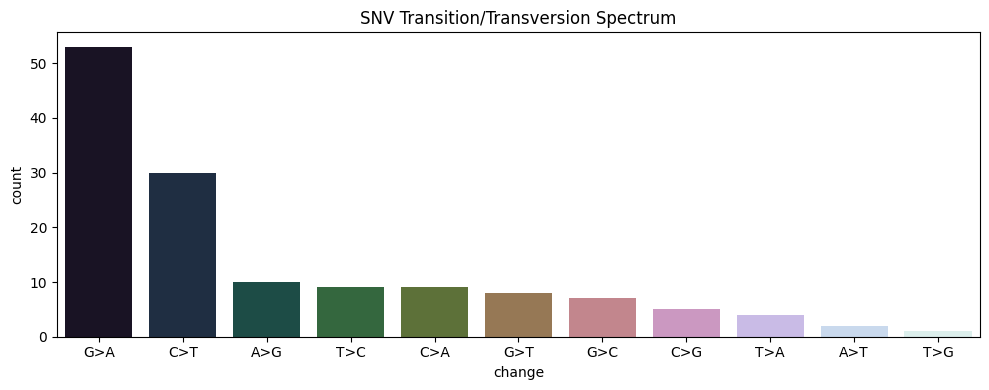

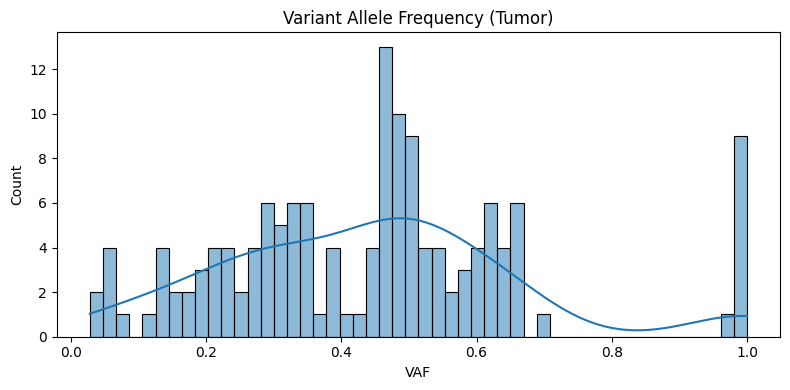

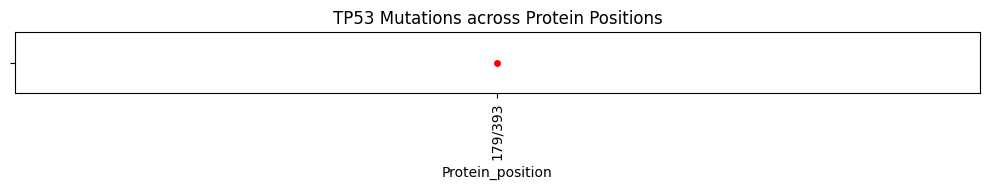

TP53 변이 개수: 1


,Hugo_Symbol,Tumor_Sample_Barcode,Variant_Classification,HGVSp_Short,Variant_Type,Chromosome,Start_Position
110,TP53,HCM-SANG-0280-C18-85A-01D-A79M-36,Missense_Mutation,p.H179R,SNP,chr17,7675076


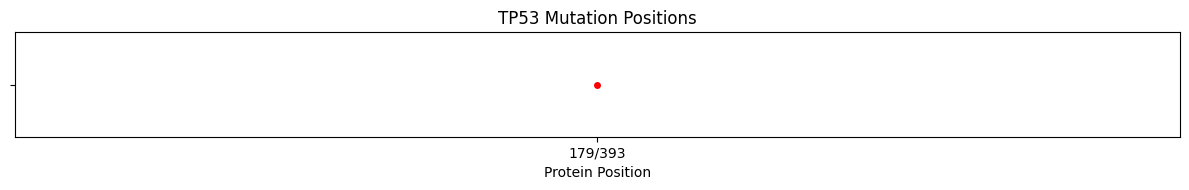

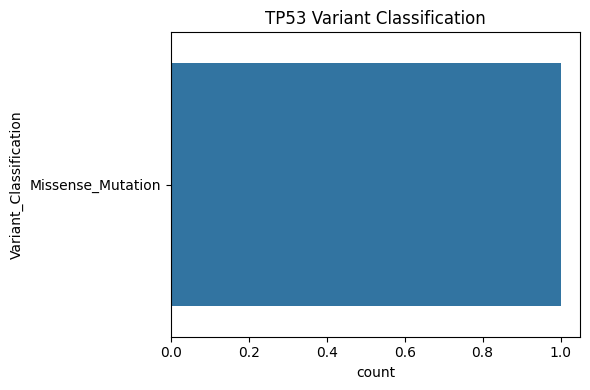

In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 파일 불러오기
maf_path = "/home/Data_Drive_8TB/kykim/Mutect2/HCM-SANG-0280-C18.maf.gz"
G3 = pd.read_csv(maf_path, sep='\t', comment='#', low_memory=False)

print("Tumor Sample:", G3["Tumor_Sample_Barcode"].unique())
print("Total variants:", len(G3))
print("Unique mutated genes:", G3['Hugo_Symbol'].nunique())
G3["Variant_Classification"].unique()

plt.figure(figsize=(10, 5))
sns.countplot(data=G3, y="Variant_Classification", order=G3["Variant_Classification"].value_counts().index)
plt.title("Variant Classification Counts")
plt.tight_layout()
plt.show()

top_genes = G3["Hugo_Symbol"].value_counts().head(20)
plt.figure(figsize=(8, 8))
sns.barplot(x=top_genes.values, y=top_genes.index, palette="viridis")
plt.title("Top 20 Mutated Genes")
plt.xlabel("Mutation Count")
plt.tight_layout()
plt.show()

snvs = G3[G3["Variant_Type"] == "SNP"].copy()
snvs["change"] = snvs["Reference_Allele"] + ">" + snvs["Tumor_Seq_Allele2"]

plt.figure(figsize=(10, 4))
sns.countplot(x=snvs["change"], order=snvs["change"].value_counts().index, palette="cubehelix")
plt.title("SNV Transition/Transversion Spectrum")
plt.tight_layout()
plt.show()

# VAF는 MAF 파일에 명시되어 있지 않지만, Tumor VAF 계산 가능할 수 있음
# 만약 VAF 컬럼이 존재한다면:
if "t_alt_count" in G3.columns and "t_depth" in G3.columns:
    G3["VAF"] = G3["t_alt_count"] / G3["t_depth"]
    plt.figure(figsize=(8, 4))
    sns.histplot(G3["VAF"].dropna(), bins=50, kde=True)
    plt.title("Variant Allele Frequency (Tumor)")
    plt.xlabel("VAF")
    plt.tight_layout()
    plt.show()

tp53 = G3[G3["Hugo_Symbol"] == "TP53"]
if not tp53.empty:
    plt.figure(figsize=(10, 2))
    sns.stripplot(x=tp53["Protein_position"].astype(str), color="red", jitter=True)
    plt.title("TP53 Mutations across Protein Positions")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

tp53_mut = G3[G3['Hugo_Symbol'] == 'TP53']
print("TP53 변이 개수:", len(tp53_mut))
display(tp53_mut[['Hugo_Symbol', 'Tumor_Sample_Barcode', 'Variant_Classification', 
                   'HGVSp_Short', 'Variant_Type', 
                  'Chromosome', 'Start_Position']])
# 단백질 위치 정보가 있는 경우
if 'Protein_position' in tp53_mut.columns:
    plt.figure(figsize=(12, 2))
    sns.stripplot(data=tp53_mut, x='Protein_position', color='red', jitter=True, size=5)
    plt.title("TP53 Mutation Positions")
    plt.xlabel("Protein Position")
    plt.tight_layout()
    plt.show()
plt.figure(figsize=(6, 4))
sns.countplot(data=tp53_mut, y="Variant_Classification", order=tp53_mut["Variant_Classification"].value_counts().index)
plt.title("TP53 Variant Classification")
plt.tight_layout()
plt.show()


Tumor Sample: ['HCM-CSHL-0237-C18-01B-01D-A78L-36']
Total variants: 124
Unique mutated genes: 121


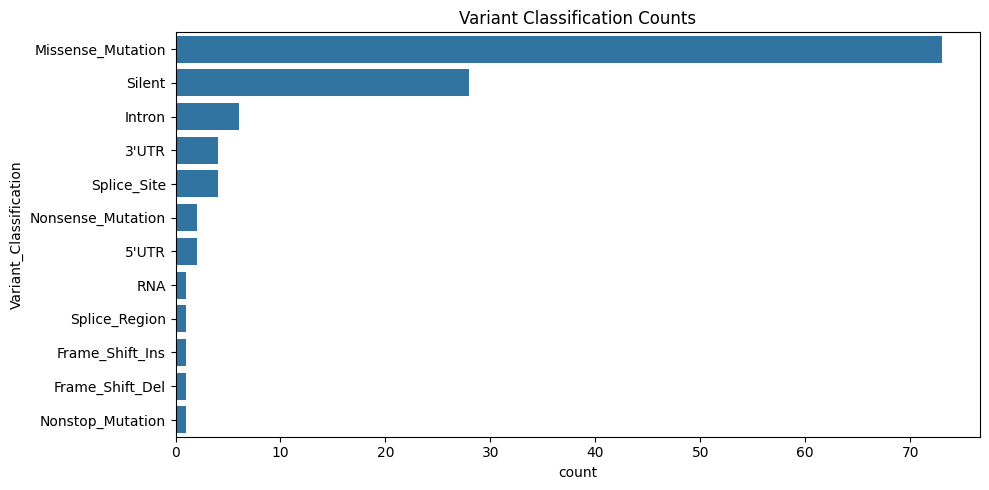

/tmp/ipykernel_321470/230692558.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genes.values, y=top_genes.index, palette="viridis")


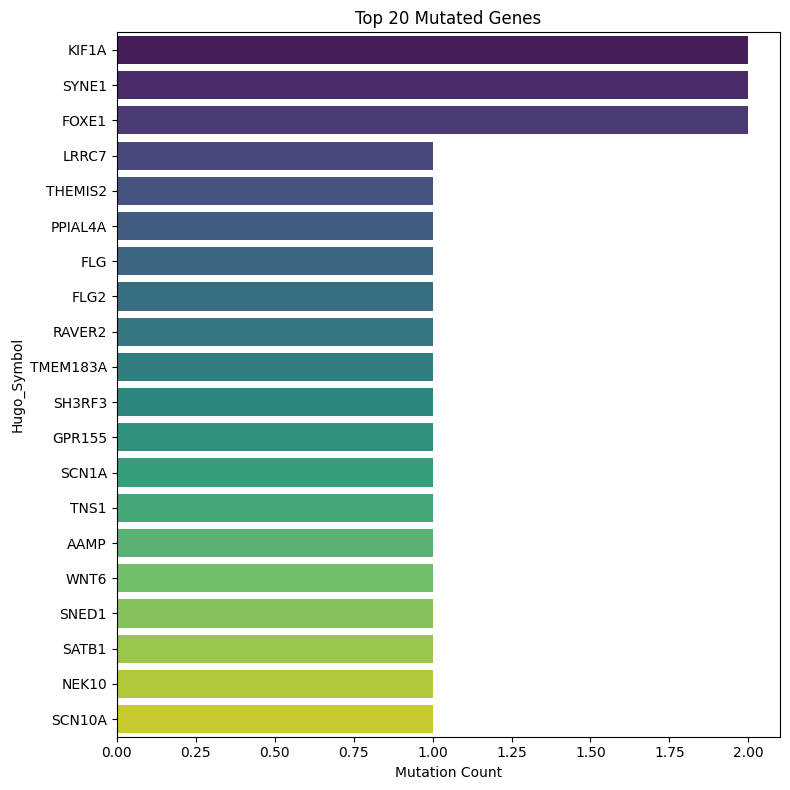

/tmp/ipykernel_321470/230692558.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=snvs["change"], order=snvs["change"].value_counts().index, palette="cubehelix")


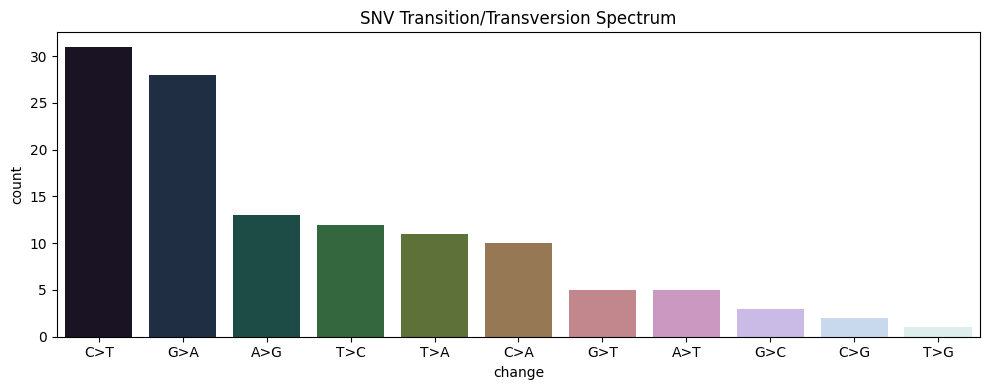

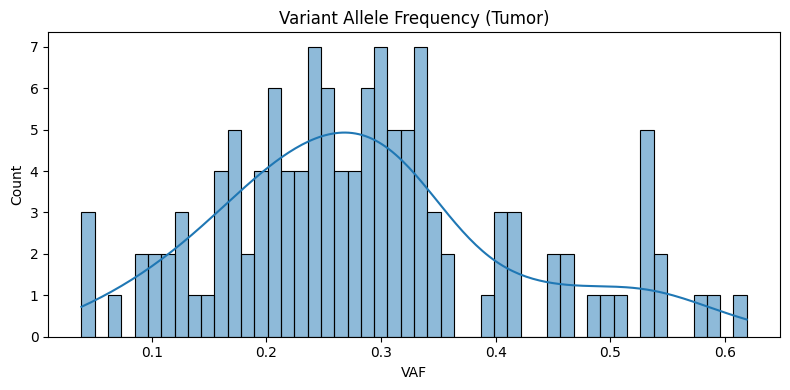

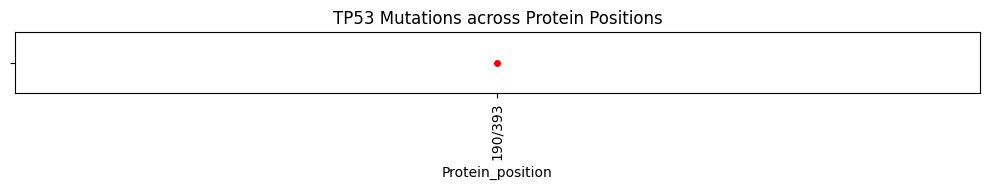

TP53 변이 개수: 1


,Hugo_Symbol,Tumor_Sample_Barcode,Variant_Classification,HGVSp_Short,Variant_Type,Chromosome,Start_Position
94,TP53,HCM-CSHL-0237-C18-01B-01D-A78L-36,Missense_Mutation,p.P190L,SNP,chr17,7674962


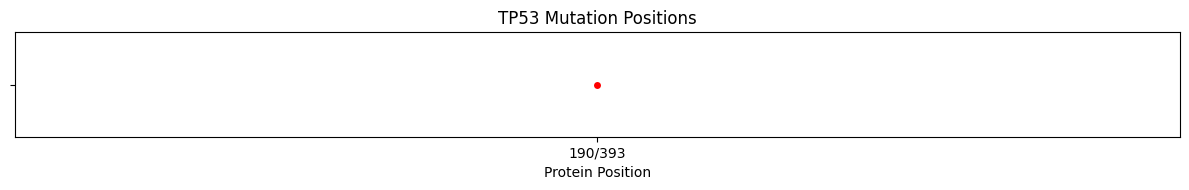

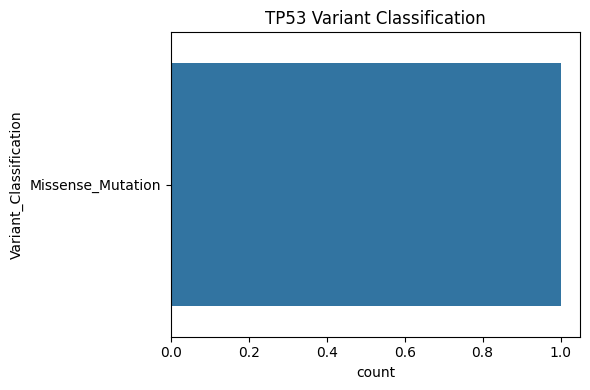

In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 파일 불러오기
maf_path = "/home/Data_Drive_8TB/kykim/Mutect2/HCM-CSHL-0237-C18.maf.gz"
G2 = pd.read_csv(maf_path, sep='\t', comment='#', low_memory=False)

print("Tumor Sample:", G2["Tumor_Sample_Barcode"].unique())
print("Total variants:", len(G2))
print("Unique mutated genes:", G2['Hugo_Symbol'].nunique())
G2["Variant_Classification"].unique()

plt.figure(figsize=(10, 5))
sns.countplot(data=G2, y="Variant_Classification", order=G2["Variant_Classification"].value_counts().index)
plt.title("Variant Classification Counts")
plt.tight_layout()
plt.show()

top_genes = G2["Hugo_Symbol"].value_counts().head(20)
plt.figure(figsize=(8, 8))
sns.barplot(x=top_genes.values, y=top_genes.index, palette="viridis")
plt.title("Top 20 Mutated Genes")
plt.xlabel("Mutation Count")
plt.tight_layout()
plt.show()

snvs = G2[G2["Variant_Type"] == "SNP"].copy()
snvs["change"] = snvs["Reference_Allele"] + ">" + snvs["Tumor_Seq_Allele2"]

plt.figure(figsize=(10, 4))
sns.countplot(x=snvs["change"], order=snvs["change"].value_counts().index, palette="cubehelix")
plt.title("SNV Transition/Transversion Spectrum")
plt.tight_layout()
plt.show()

# VAF는 MAF 파일에 명시되어 있지 않지만, Tumor VAF 계산 가능할 수 있음
# 만약 VAF 컬럼이 존재한다면:
if "t_alt_count" in G2.columns and "t_depth" in G2.columns:
    G2["VAF"] = G2["t_alt_count"] / G2["t_depth"]
    plt.figure(figsize=(8, 4))
    sns.histplot(G2["VAF"].dropna(), bins=50, kde=True)
    plt.title("Variant Allele Frequency (Tumor)")
    plt.xlabel("VAF")
    plt.tight_layout()
    plt.show()

tp53 = G2[G2["Hugo_Symbol"] == "TP53"]
if not tp53.empty:
    plt.figure(figsize=(10, 2))
    sns.stripplot(x=tp53["Protein_position"].astype(str), color="red", jitter=True)
    plt.title("TP53 Mutations across Protein Positions")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

tp53_mut = G2[G2['Hugo_Symbol'] == 'TP53']
print("TP53 변이 개수:", len(tp53_mut))
display(tp53_mut[['Hugo_Symbol', 'Tumor_Sample_Barcode', 'Variant_Classification', 
                   'HGVSp_Short', 'Variant_Type', 
                  'Chromosome', 'Start_Position']])
# 단백질 위치 정보가 있는 경우
if 'Protein_position' in tp53_mut.columns:
    plt.figure(figsize=(12, 2))
    sns.stripplot(data=tp53_mut, x='Protein_position', color='red', jitter=True, size=5)
    plt.title("TP53 Mutation Positions")
    plt.xlabel("Protein Position")
    plt.tight_layout()
    plt.show()
plt.figure(figsize=(6, 4))
sns.countplot(data=tp53_mut, y="Variant_Classification", order=tp53_mut["Variant_Classification"].value_counts().index)
plt.title("TP53 Variant Classification")
plt.tight_layout()
plt.show()


Tumor Sample: ['HCM-CSHL-0142-C18-85A-01D-A77E-36']
Total variants: 119
Unique mutated genes: 116


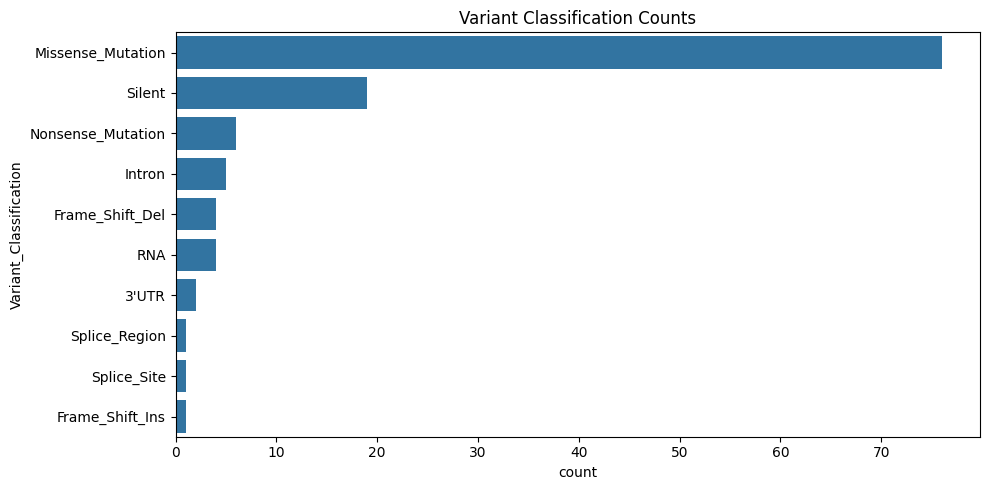

/tmp/ipykernel_321470/4137605010.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genes.values, y=top_genes.index, palette="viridis")


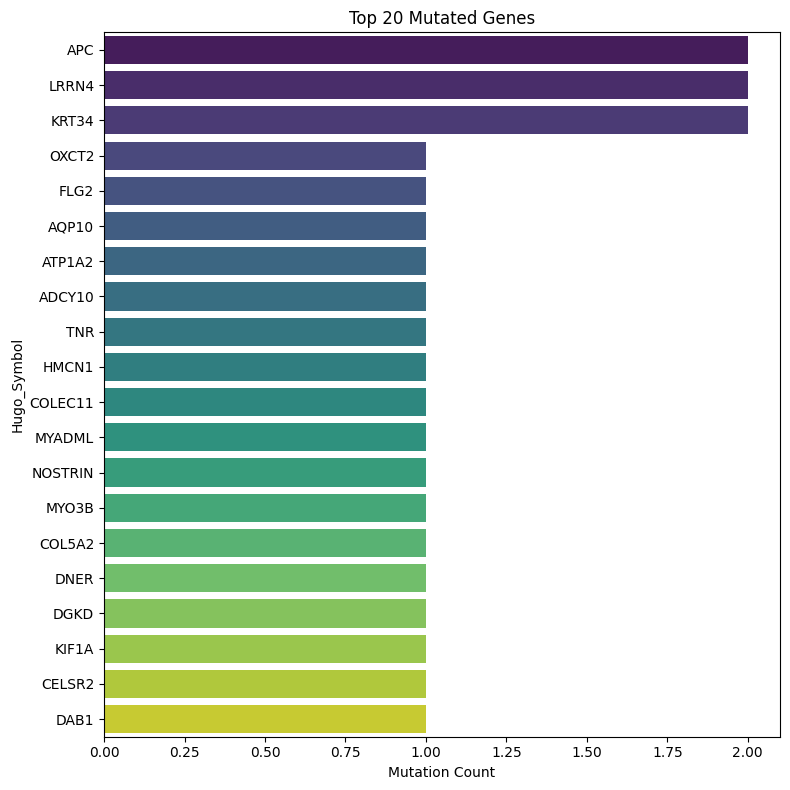

/tmp/ipykernel_321470/4137605010.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=snvs["change"], order=snvs["change"].value_counts().index, palette="cubehelix")


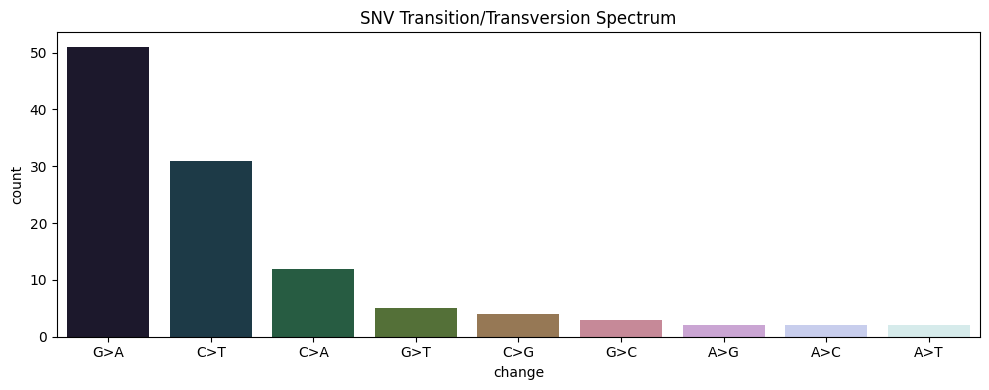

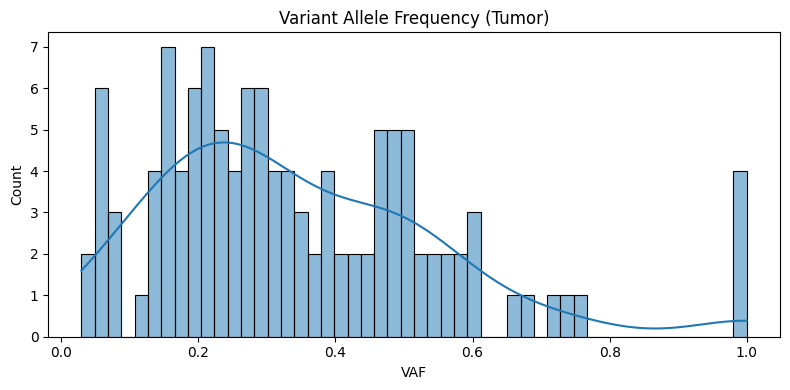

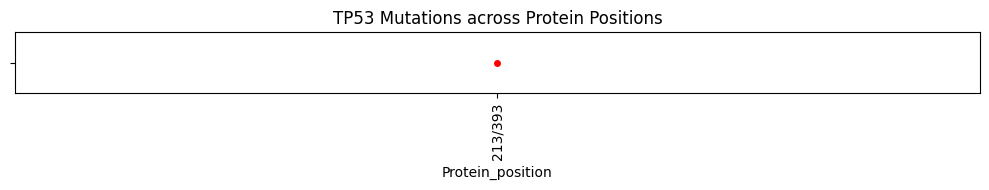

TP53 변이 개수: 1


,Hugo_Symbol,Tumor_Sample_Barcode,Variant_Classification,HGVSp_Short,Variant_Type,Chromosome,Start_Position
88,TP53,HCM-CSHL-0142-C18-85A-01D-A77E-36,Nonsense_Mutation,p.R213*,SNP,chr17,7674894


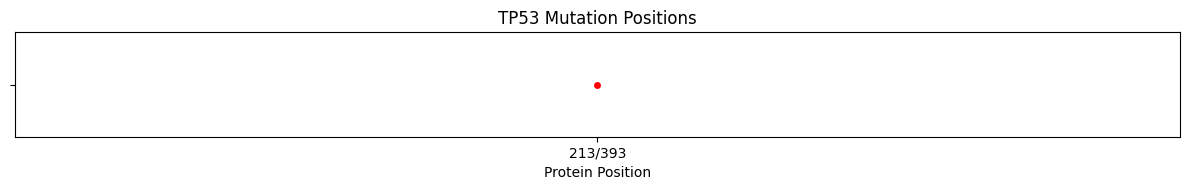

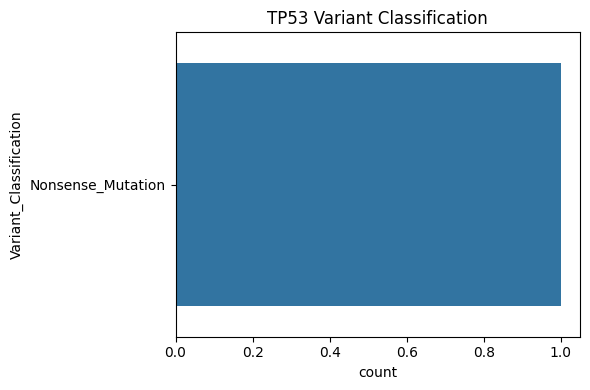

In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 파일 불러오기
maf_path = "/home/Data_Drive_8TB/kykim/Mutect2/HCM-CSHL-0142-C18.maf.gz"
GB = pd.read_csv(maf_path, sep='\t', comment='#', low_memory=False)

print("Tumor Sample:", GB["Tumor_Sample_Barcode"].unique())
print("Total variants:", len(GB))
print("Unique mutated genes:", GB['Hugo_Symbol'].nunique())
GB["Variant_Classification"].unique()

plt.figure(figsize=(10, 5))
sns.countplot(data=GB, y="Variant_Classification", order=GB["Variant_Classification"].value_counts().index)
plt.title("Variant Classification Counts")
plt.tight_layout()
plt.show()

top_genes = GB["Hugo_Symbol"].value_counts().head(20)
plt.figure(figsize=(8, 8))
sns.barplot(x=top_genes.values, y=top_genes.index, palette="viridis")
plt.title("Top 20 Mutated Genes")
plt.xlabel("Mutation Count")
plt.tight_layout()
plt.show()

snvs = GB[GB["Variant_Type"] == "SNP"].copy()
snvs["change"] = snvs["Reference_Allele"] + ">" + snvs["Tumor_Seq_Allele2"]

plt.figure(figsize=(10, 4))
sns.countplot(x=snvs["change"], order=snvs["change"].value_counts().index, palette="cubehelix")
plt.title("SNV Transition/Transversion Spectrum")
plt.tight_layout()
plt.show()

# VAF는 MAF 파일에 명시되어 있지 않지만, Tumor VAF 계산 가능할 수 있음
# 만약 VAF 컬럼이 존재한다면:
if "t_alt_count" in GB.columns and "t_depth" in GB.columns:
    GB["VAF"] = GB["t_alt_count"] / GB["t_depth"]
    plt.figure(figsize=(8, 4))
    sns.histplot(GB["VAF"].dropna(), bins=50, kde=True)
    plt.title("Variant Allele Frequency (Tumor)")
    plt.xlabel("VAF")
    plt.tight_layout()
    plt.show()

tp53 = GB[GB["Hugo_Symbol"] == "TP53"]
if not tp53.empty:
    plt.figure(figsize=(10, 2))
    sns.stripplot(x=tp53["Protein_position"].astype(str), color="red", jitter=True)
    plt.title("TP53 Mutations across Protein Positions")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

tp53_mut = GB[GB['Hugo_Symbol'] == 'TP53']
print("TP53 변이 개수:", len(tp53_mut))
display(tp53_mut[['Hugo_Symbol', 'Tumor_Sample_Barcode', 'Variant_Classification', 
                   'HGVSp_Short', 'Variant_Type', 
                  'Chromosome', 'Start_Position']])
# 단백질 위치 정보가 있는 경우
if 'Protein_position' in tp53_mut.columns:
    plt.figure(figsize=(12, 2))
    sns.stripplot(data=tp53_mut, x='Protein_position', color='red', jitter=True, size=5)
    plt.title("TP53 Mutation Positions")
    plt.xlabel("Protein Position")
    plt.tight_layout()
    plt.show()
plt.figure(figsize=(6, 4))
sns.countplot(data=tp53_mut, y="Variant_Classification", order=tp53_mut["Variant_Classification"].value_counts().index)
plt.title("TP53 Variant Classification")
plt.tight_layout()
plt.show()


In [211]:
G3[G3['Hugo_Symbol'] == 'APC']

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,case_id,GDC_FILTER,COSMIC,hotspot,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers,VAF
40,APC,324,BI,GRCh38,chr5,112838007,112838007,+,Nonsense_Mutation,SNP,...,3dab73f4-1fd2-440d-a194-4368818ee701,NaN,COSM19058,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,1.0


In [212]:
G3[G3['Hugo_Symbol'] == 'APC']['VAF']

40    1.0
Name: VAF, dtype: float64

In [213]:
total

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,GDC_FILTER,COSMIC,hotspot,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers,VAF,stage
0,OXCT2,64064,BI,GRCh38,chr1,39771136,39771136,+,Silent,SNP,...,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,0.243590,GB
1,DAB1,1600,BI,GRCh38,chr1,57145296,57145296,+,Frame_Shift_Del,DEL,...,NaN,NaN,N,Unknown,NaN,NaN,NaN,mutect2;pindel;varscan2,0.549133,GB
2,CELSR2,1952,BI,GRCh38,chr1,109250884,109250884,+,Nonsense_Mutation,SNP,...,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,0.279597,GB
3,FLG,2312,BI,GRCh38,chr1,152309256,152309256,+,Missense_Mutation,SNP,...,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,0.187970,GB
4,FLG2,388698,BI,GRCh38,chr1,152352308,152352308,+,Silent,SNP,...,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,0.230769,GB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,EFCAB6,64800,BI,GRCh38,chr22,43600181,43600181,+,Missense_Mutation,SNP,...,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,0.297619,G3
382,ALG12,79087,BI,GRCh38,chr22,49904439,49904444,+,Frame_Shift_Del,DEL,...,NaN,NaN,N,Unknown,NaN,NaN,NaN,pindel;varscan2*,0.549199,G3
383,AMER1,139285,BI,GRCh38,chrX,64191366,64191366,+,Nonsense_Mutation,SNP,...,NaN,COSM174910;COSM174911,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,1.000000,G3
384,DIAPH2,1730,BI,GRCh38,chrX,96942119,96942119,+,Missense_Mutation,SNP,...,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,0.993103,G3


In [214]:
import pandas as pd

# 각 DataFrame에 stage 컬럼 추가
GB["stage"] = "GB"
G2["stage"] = "G2"
G3["stage"] = "G3"

# 세 객체를 하나의 total 객체로 합치기
total = pd.concat([GB, G2, G3], ignore_index=True)


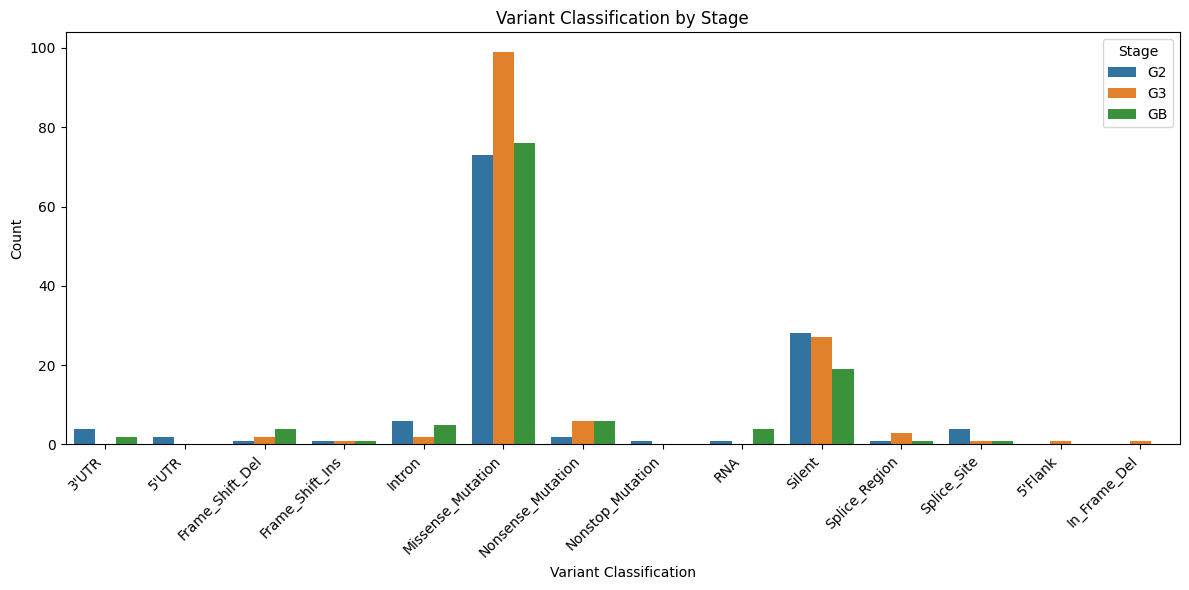

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

# variant classification을 stage 기준으로 group하여 count
vc_counts = total.groupby(['stage', 'Variant_Classification']).size().reset_index(name='count')

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=vc_counts, x='Variant_Classification', y='count', hue='stage')

# 보기 좋게 회전
plt.xticks(rotation=45, ha='right')
plt.title("Variant Classification by Stage")
plt.xlabel("Variant Classification")
plt.ylabel("Count")
plt.legend(title="Stage")
plt.tight_layout()
plt.show()


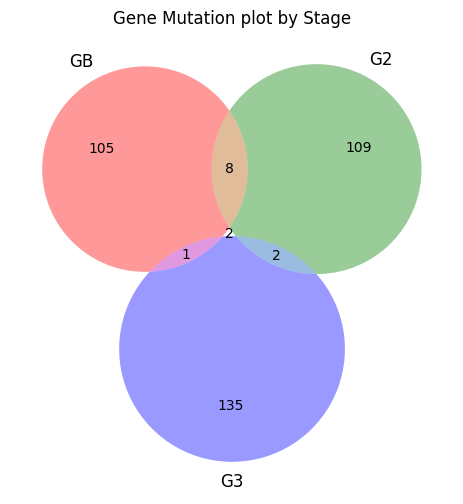

▶ GB ∩ G2:
['APC', 'FLG', 'FLG2', 'KIF1A', 'MLIP', 'NLRP2', 'PTPRM', 'RIMS2', 'SPATA31A6', 'TP53']

▶ GB ∩ G3:
['APC', 'SDK1', 'TP53']

▶ G2 ∩ G3:
['APC', 'SCN1A', 'SYNE1', 'TP53']

▶ GB ∩ G2 ∩ G3:
['APC', 'TP53']


In [216]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# 각 group에서 유전자 리스트 추출
genes_GB = set(GB["Hugo_Symbol"].dropna().unique())
genes_G2 = set(G2["Hugo_Symbol"].dropna().unique())
genes_G3 = set(G3["Hugo_Symbol"].dropna().unique())

# Venn 다이어그램 그리기
plt.figure(figsize=(8, 6))
venn3([genes_GB, genes_G2, genes_G3], set_labels=("GB", "G2", "G3"))
plt.title("Gene Mutation plot by Stage")
plt.show()
# 교집합 계산
overlap_GB_G2 = genes_GB & genes_G2
overlap_GB_G3 = genes_GB & genes_G3
overlap_G2_G3 = genes_G2 & genes_G3
overlap_GB_G2_G3 = genes_GB & genes_G2 & genes_G3

# 각각의 교집합 결과 출력
print("▶ GB ∩ G2:")
print(sorted(overlap_GB_G2))
print("\n▶ GB ∩ G3:")
print(sorted(overlap_GB_G3))
print("\n▶ G2 ∩ G3:")
print(sorted(overlap_G2_G3))
print("\n▶ GB ∩ G2 ∩ G3:")
print(sorted(overlap_GB_G2_G3))


/tmp/ipykernel_321470/3769256007.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=snvs_apc["change"], order=snvs_apc["change"].value_counts().index, palette="cubehelix")


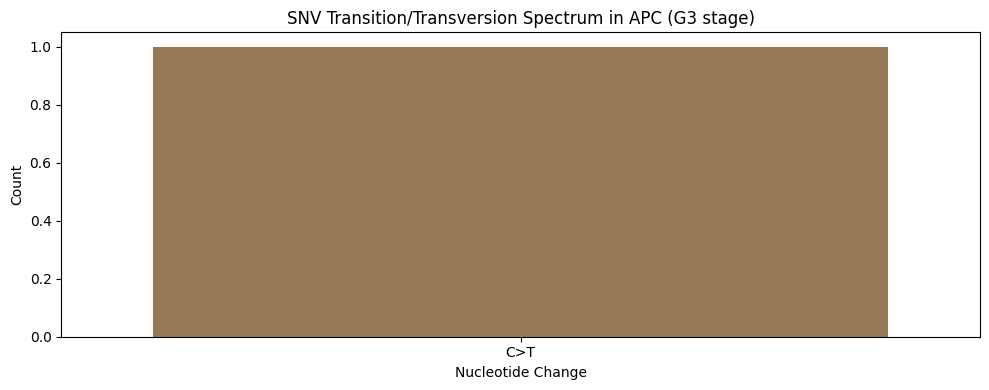

In [217]:
# APC 유전자에서 SNP만 필터링
snvs_apc = G3[(G3["Variant_Type"] == "SNP") & (G3["Hugo_Symbol"] == "APC")].copy()

# 변이 유형 형성 (예: C>T)
snvs_apc["change"] = snvs_apc["Reference_Allele"] + ">" + snvs_apc["Tumor_Seq_Allele2"]

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.countplot(x=snvs_apc["change"], order=snvs_apc["change"].value_counts().index, palette="cubehelix")
plt.title("SNV Transition/Transversion Spectrum in APC (G3 stage)")
plt.xlabel("Nucleotide Change")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [218]:
print(list(total.columns))


['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Variant_Classification', 'Variant_Type', 'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'dbSNP_RS', 'dbSNP_Val_Status', 'Tumor_Sample_Barcode', 'Matched_Norm_Sample_Barcode', 'Match_Norm_Seq_Allele1', 'Match_Norm_Seq_Allele2', 'Tumor_Validation_Allele1', 'Tumor_Validation_Allele2', 'Match_Norm_Validation_Allele1', 'Match_Norm_Validation_Allele2', 'Verification_Status', 'Validation_Status', 'Mutation_Status', 'Sequencing_Phase', 'Sequence_Source', 'Validation_Method', 'Score', 'BAM_File', 'Sequencer', 'Tumor_Sample_UUID', 'Matched_Norm_Sample_UUID', 'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'Exon_Number', 't_depth', 't_ref_count', 't_alt_count', 'n_depth', 'n_ref_count', 'n_alt_count', 'all_effects', 'Allele', 'Gene', 'Feature', 'Feature_type', 'One_Consequence', 'Consequence', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Cod

In [266]:
import pandas as pd

# 각각의 COSMIC 정보 추출 (Series)
tp53_gb = GB[GB['Hugo_Symbol'] == 'TP53']['COSMIC'].reset_index(drop=True)
apc_gb  = GB[GB['Hugo_Symbol'] == 'APC']['COSMIC'].reset_index(drop=True)
tp53_g2 = G2[G2['Hugo_Symbol'] == 'TP53']['COSMIC'].reset_index(drop=True)
apc_g2  = G2[G2['Hugo_Symbol'] == 'APC']['COSMIC'].reset_index(drop=True)
tp53_g3 = G3[G3['Hugo_Symbol'] == 'TP53']['COSMIC'].reset_index(drop=True)
apc_g3  = G3[G3['Hugo_Symbol'] == 'APC']['COSMIC'].reset_index(drop=True)

# 길이 맞추기 (NaN은 자동 채워짐)
cosmic_df = pd.concat([tp53_gb, apc_gb, tp53_g2, apc_g2, tp53_g3, apc_g3], axis=1)

# 컬럼 이름 지정
cosmic_df.columns = ['GB_TP53', 'GB_APC', 'G2_TP53', 'G2_APC', 'G3_TP53', 'G3_APC']

# 결과 출력
print(cosmic_df)


                                             GB_TP53     GB_APC  \
0  COSM10654;COSM1638393;COSM3378350;COSM99615;CO...        NaN   
1                                                NaN  COSM19085   

                                             G2_TP53 G2_APC  \
0  COSM1386772;COSM1386773;COSM1386774;COSM138677...    NaN   
1                                                NaN    NaN   

                                             G3_TP53     G3_APC  
0  COSM10889;COSM1645241;COSM214222;COSM214223;CO...  COSM19058  
1                                                NaN        NaN  


In [220]:
GB[GB['Hugo_Symbol'] == 'TP53']['Variant_Classification'].value_counts()

Variant_Classification
Nonsense_Mutation    1
Name: count, dtype: int64

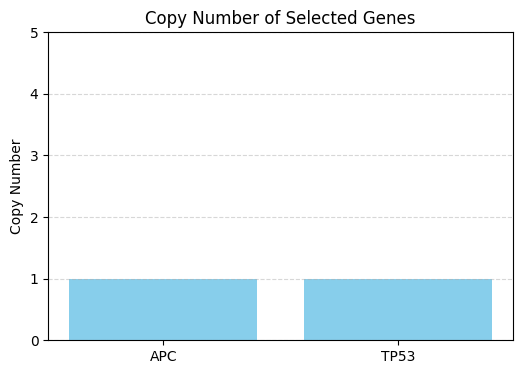

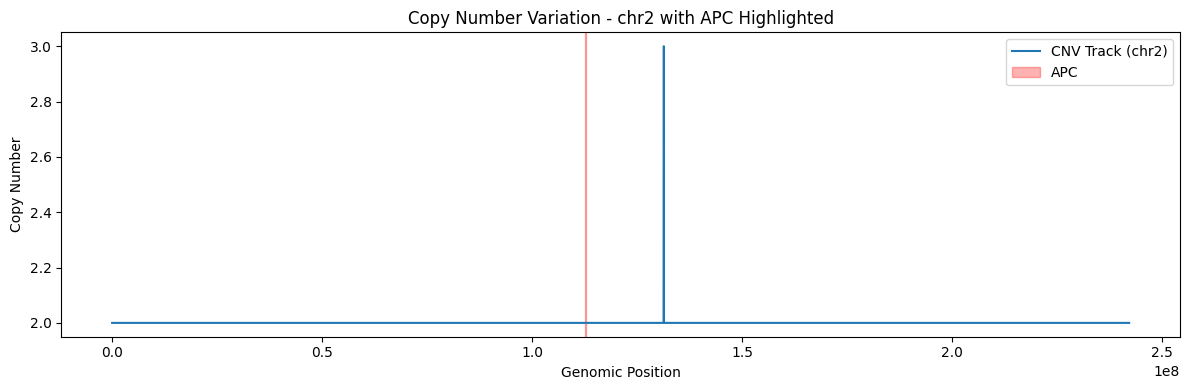

In [221]:
import pandas as pd
import matplotlib.pyplot as plt

# TSV 파일 불러오기
df = pd.read_csv("/home/Data_Drive_8TB/kykim/Mutect2/HCM-SANG-0280-C18.tsv", sep='\t')

# 관심 유전자 필터링
genes_of_interest = ['TP53', 'APC']
df_filtered = df[df['gene_name'].isin(genes_of_interest)]

# 시각화
plt.figure(figsize=(6, 4))
plt.bar(df_filtered['gene_name'], df_filtered['copy_number'], color='skyblue')
plt.title("Copy Number of Selected Genes")
plt.ylabel("Copy Number")
plt.ylim(0, df['copy_number'].max() + 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

import seaborn as sns

# 전체 CNV 결과 중 chr17 (TP53 위치) 필터링
df_chr17 = df[df['chromosome'] == 'chr2']

# 시각화
plt.figure(figsize=(12, 4))
sns.lineplot(x='start', y='copy_number', data=df_chr17, label='CNV Track (chr2)')
# TP53 위치 표시
tp53_info = df[df['gene_name'] == 'APC']
for _, row in tp53_info.iterrows():
    plt.axvspan(row['start'], row['end'], color='red', alpha=0.3, label='APC')

plt.title("Copy Number Variation - chr2 with APC Highlighted")
plt.xlabel("Genomic Position")
plt.ylabel("Copy Number")
plt.legend()
plt.tight_layout()
plt.show()


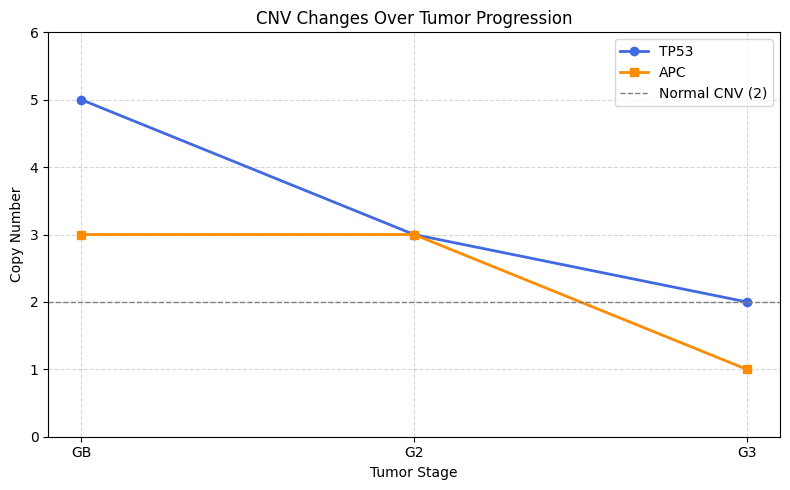

In [222]:
import matplotlib.pyplot as plt

# 시계열 단계
stages = ['GB', 'G2', 'G3']

# CNV 값
tp53_cnv = [5, 3, 2]
apc_cnv = [3, 3, 1]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(stages, tp53_cnv, marker='o', label='TP53', linewidth=2, color='royalblue')
plt.plot(stages, apc_cnv, marker='s', label='APC', linewidth=2, color='darkorange')

# 기준선 (정상 CNV = 2)
plt.axhline(y=2, color='gray', linestyle='--', linewidth=1, label='Normal CNV (2)')

# 꾸미기
plt.title('CNV Changes Over Tumor Progression')
plt.xlabel('Tumor Stage')
plt.ylabel('Copy Number')
plt.ylim(0, 6)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [325]:
# 메틸화 데이터 읽기
meth = pd.read_csv("/home/Data_Drive_8TB/kykim/Mutect2/HCM-CSHL-0142-C18.txt", sep="\t", header=None, names=["CpG", "Beta"])
# 1. Annotation 파일 불러오기
anno = pd.read_csv("/home/Data_Drive_8TB/kykim/Mutect2/HumanMethylation450_15017482_v1-2.csv", skiprows=7)
tp53_cpgs = anno[anno['UCSC_RefGene_Name'].str.contains("TP53", na=False)]
apc_cpgs = anno[anno['UCSC_RefGene_Name'].str.contains("APC", na=False)]
pax5_cpgs = anno[anno['UCSC_RefGene_Name'].str.contains("PAX5", na=False)]
# TP53 관련 CpG β값 필터링
tp53_meth = meth[meth['CpG'].isin(tp53_cpgs['IlmnID'])]

/tmp/ipykernel_321470/2833650064.py:4: DtypeWarning: Columns (2,4,11,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  anno = pd.read_csv("/home/Data_Drive_8TB/kykim/Mutect2/HumanMethylation450_15017482_v1-2.csv", skiprows=7)


In [326]:
import pandas as pd



# 2. 필요한 컬럼만 추출
anno_slim = anno[['IlmnID', 'UCSC_RefGene_Name', 'UCSC_RefGene_Group', 'CHR', 'MAPINFO','UCSC_CpG_Islands_Name']]

# 3. 유전자별 CpG ID 목록 보기 (예: TP53)
tp53_anno = anno_slim[
    anno_slim['UCSC_RefGene_Name'].str.contains('TP53', na=False)
]


In [327]:
# IlmnID와 유전자명만 남긴 간단한 테이블 준비
gene_map = tp53_anno[['IlmnID', 'UCSC_RefGene_Name','UCSC_CpG_Islands_Name']].drop_duplicates()

# tp53_meth의 CpG와 IlmnID를 매핑하여 유전자명 병합
tp53_meth = tp53_meth.merge(gene_map, left_on='CpG', right_on='IlmnID', how='left')

# 컬럼 정리: 'UCSC_RefGene_Name' → 'gene'
tp53_meth.rename(columns={'UCSC_RefGene_Name': 'gene'}, inplace=True)

# IlmnID 컬럼 제거 (필요 없을 경우)
tp53_meth.drop(columns='IlmnID', inplace=True)


In [328]:
# gene 열에서 정확히 TP53이 포함된 경우만 필터링
filtered = tp53_meth[
    tp53_meth['gene'].notna() &
    tp53_meth['gene'].apply(lambda g: 'TP53' in [x.strip() for x in str(g).split(';')])
]


In [329]:
filtered_sorted = filtered.sort_values(by='Beta', ascending=False)
filtered_sorted

,CpG,Beta,gene,UCSC_CpG_Islands_Name
96,cg10792831,0.956609,TP53;TP53;TP53;TP53;TP53;TP53;TP53;TP53;TP53;TP53,NaN
166,cg18198734,0.943582,TP53;TP53;TP53;TP53;TP53;TP53;TP53,NaN
20,cg02087342,0.925398,TP53;TP53;TP53;TP53;TP53;TP53;TP53,NaN
61,cg06365412,0.921354,TP53;TP53;TP53;TP53,NaN
152,cg16397722,0.911411,TP53;TP53;TP53;TP53;TP53;TP53;TP53,NaN
106,cg12041429,0.876276,TP53;TP53;TP53;TP53,chr17:7589290-7589503
105,cg12041075,0.858993,TP53;TP53;TP53;TP53;TP53;TP53;TP53,NaN
123,cg13468400,0.706165,TP53;TP53;TP53;TP53;TP53;TP53;TP53,NaN
72,cg07760161,0.658126,TP53;WRAP53;TP53;TP53;TP53,chr17:7589290-7589503
113,cg12373934,0.085423,WRAP53;TP53;WRAP53;TP53;WRAP53;TP53;TP53;WRAP53,chr17:7591494-7591839


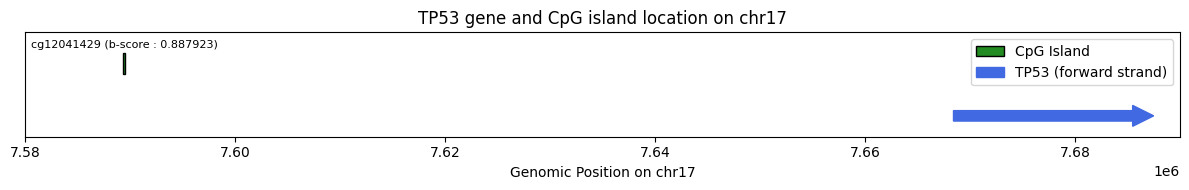

In [248]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

		
tp53_start = 7668421
tp53_end = 7687490
cpg_start = 7589290
cpg_end = 7589503
plot_start = 7580000
plot_end = 7690000

# 그래프 설정
fig, ax = plt.subplots(figsize=(12, 2))

# CpG island (녹색 블록)
ax.add_patch(patches.Rectangle(
    (cpg_start, 0.6), cpg_end - cpg_start, 0.2,
    facecolor='forestgreen', edgecolor='black', label='CpG Island'
))

# → cg12041429 텍스트를 블록 위에 표시
cg_site = (cpg_start + cpg_end) // 2
ax.text(cg_site, 0.85, "cg12041429 (b-score : 0.887923)", ha='center', fontsize=8, color='black')

# TP53 유전자 (강조된 파란 화살표)
arrow_length = tp53_end - tp53_start
ax.add_patch(patches.FancyArrow(
    x=tp53_start, y=0.2, dx=arrow_length, dy=0,
    width=0.1, head_width=0.2, head_length=2000,
    length_includes_head=True, color='royalblue',
    label='TP53 (forward strand)'
))

# 축/라벨 설정
ax.set_xlim(plot_start, plot_end)
ax.set_ylim(0, 1)
ax.set_xlabel("Genomic Position on chr17")
ax.set_yticks([])
ax.set_title("TP53 gene and CpG island location on chr17")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


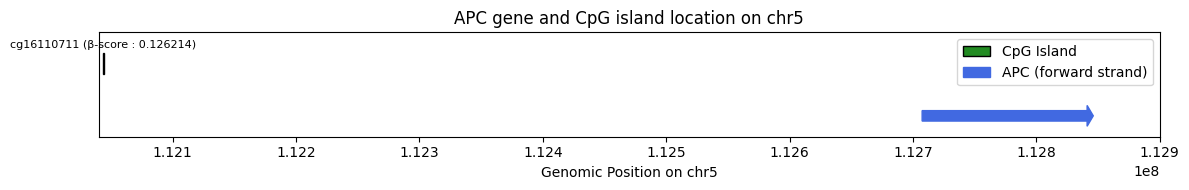

In [249]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

tp53_start = 112707498
tp53_end = 112846239
cpg_start = 112043079
cpg_end = 112043917
plot_start = 112040000
plot_end = 112900000

# 그래프 설정
fig, ax = plt.subplots(figsize=(12, 2))

# CpG island (녹색 블록)
ax.add_patch(patches.Rectangle(
    (cpg_start, 0.6), cpg_end - cpg_start, 0.2,
    facecolor='forestgreen', edgecolor='black', label='CpG Island'
))

# → cg12041429 텍스트를 블록 위에 표시
cg_site = (cpg_start + cpg_end) // 2
ax.text(cg_site, 0.85, "cg16110711 (β-score : 0.126214)", ha='center', fontsize=8, color='black')

# TP53 유전자 (강조된 파란 화살표)
arrow_length = tp53_end - tp53_start
ax.add_patch(patches.FancyArrow(
    x=tp53_start, y=0.2, dx=arrow_length, dy=0,
    width=0.1, head_width=0.2, head_length=5000,
    length_includes_head=True, color='royalblue',
    label='APC (forward strand)'
))

# 축/라벨 설정
ax.set_xlim(plot_start, plot_end)
ax.set_ylim(0, 1)
ax.set_xlabel("Genomic Position on chr5")
ax.set_yticks([])
ax.set_title("APC gene and CpG island location on chr5")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


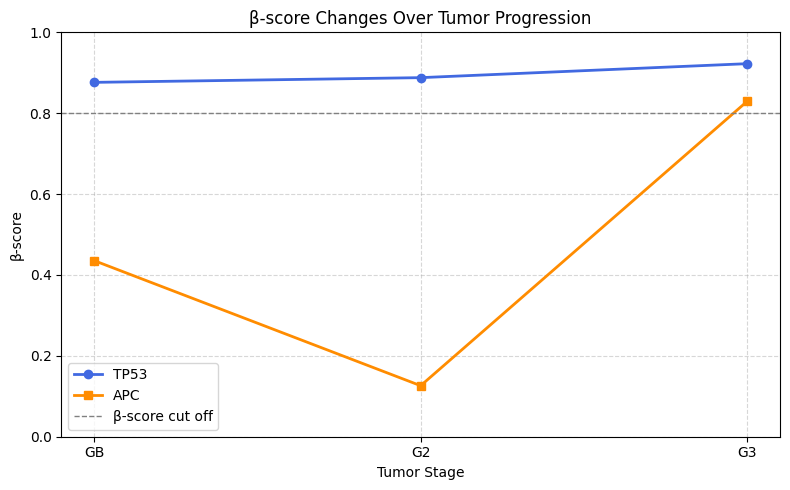

In [236]:
import matplotlib.pyplot as plt

# 시계열 단계
stages = ['GB', 'G2', 'G3']

# CNV 값
tp53_cnv = [0.876276,0.887923,0.922516]
apc_cnv = [0.435677, 0.126214, 0.829772]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(stages, tp53_cnv, marker='o', label='TP53', linewidth=2, color='royalblue')
plt.plot(stages, apc_cnv, marker='s', label='APC', linewidth=2, color='darkorange')

# 기준선 (정상 CNV = 2)
plt.axhline(y=0.8, color='gray', linestyle='--', linewidth=1, label='β-score cut off')

# 꾸미기
plt.title('β-score Changes Over Tumor Progression')
plt.xlabel('Tumor Stage')
plt.ylabel('β-score')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [309]:
import pandas as pd
from scipy.stats import ttest_ind
import numpy as np
from statsmodels.stats.multitest import multipletests

# 파일 경로
base_path = '/home/Data_Drive_8TB/kykim/Mutect2/'

# 데이터 불러오기 (주석은 건너뛰기)
gb = pd.read_csv(base_path + 'GB_bulkseq.tsv', sep='\t')
g2 = pd.read_csv(base_path + 'G2_bulkseq.tsv', sep='\t')
g3 = pd.read_csv(base_path + 'G3_bulkseq.tsv', sep='\t')

# 첫 번째 열을 제거하고 인덱스로 설정
gb = gb.drop(columns=gb.columns[0])  # 첫 번째 열 제거
g2 = g2.drop(columns=g2.columns[0])  # 첫 번째 열 제거
g3 = g3.drop(columns=g3.columns[0])  # 첫 번째 열 제거

    

In [310]:
gb = gb[['gene_name', 'fpkm_uq_unstranded']].rename(columns={'fpkm_uq_unstranded': 'GB'})
g2 = g2[['gene_name', 'fpkm_uq_unstranded']].rename(columns={'fpkm_uq_unstranded': 'G2'})
g3 = g3[['gene_name', 'fpkm_uq_unstranded']].rename(columns={'fpkm_uq_unstranded': 'G3'})

df = gb
df['G2'] = g2['G2']
df['G3'] = g3['G3']
df

,gene_name,GB,G2,G3
0,TSPAN6,77.5066,40.9753,42.9676
1,TNMD,1.7050,1.1404,0.3123
2,DPM1,81.6624,78.2255,138.9423
3,SCYL3,4.4119,4.6361,1.6074
4,C1orf112,2.8404,3.3295,0.8030
...,...,...,...,...
60655,AC008763.4,0.0000,0.0000,0.0000
60656,AL592295.6,3.3087,1.6384,3.4694
60657,AC006486.3,0.0000,0.0000,0.0000
60658,AL391628.1,0.0263,0.0099,0.0000


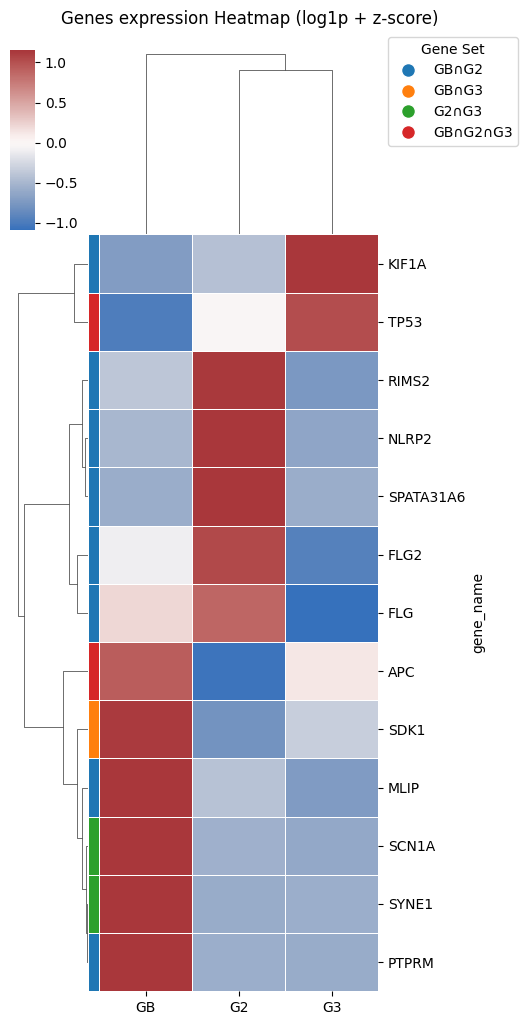

In [311]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 유전자 소속 정보 정의
gene_sets = {
    "GB∩G2": ['FLG', 'FLG2', 'KIF1A', 'MLIP', 'NLRP2', 'PTPRM', 'RIMS2', 'SPATA31A6'],
    "GB∩G3": ['SDK1'],
    "G2∩G3": ['SCN1A', 'SYNE1'],
    "GB∩G2∩G3": ['APC', 'TP53']}

# 유전자 → 집합 이름 매핑
gene_labels = {}
for label, genes in gene_sets.items():
    for g in genes:
        gene_labels[g] = label

# 유전자 리스트 (중복 제거)
selected_genes = list(gene_labels.keys())

# 1. log1p
df_log = df.copy()
df_log[['GB', 'G2', 'G3']] = np.log1p(df_log[['GB', 'G2', 'G3']])

# 2. 유전자 선택 및 row-wise z-score
df_sel = df_log[df_log['gene_name'].isin(selected_genes)].copy()
df_sel = df_sel.set_index('gene_name')
df_z = df_sel[['GB', 'G2', 'G3']].copy()
df_z = df_z.sub(df_z.mean(axis=1), axis=0).div(df_z.std(axis=1), axis=0)

# 3. 유전자 라벨 색상 매핑
label_colors = {
    "GB∩G2": "#1f77b4",       # blue
    "GB∩G3": "#ff7f0e",       # orange
    "G2∩G3": "#2ca02c",       # green
    "GB∩G2∩G3": "#d62728",     # red
}
row_colors = df_z.index.map(lambda g: label_colors[gene_labels[g]])

# 4. clustermap 그리기
g = sns.clustermap(df_z, 
                   cmap="vlag", 
                   center=0, 
                   linewidths=0.5, 
                   figsize=(5, 10),
                   method='average',
                   metric='euclidean',
                   row_colors=row_colors)

# 범례 추가
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
           for color in label_colors.values()]
labels = list(label_colors.keys())
g.fig.legend(handles, labels, title="Gene Set", loc="upper right", bbox_to_anchor=(1.05, 1))

plt.suptitle("Genes expression Heatmap (log1p + z-score)", y=1.02)
plt.show()


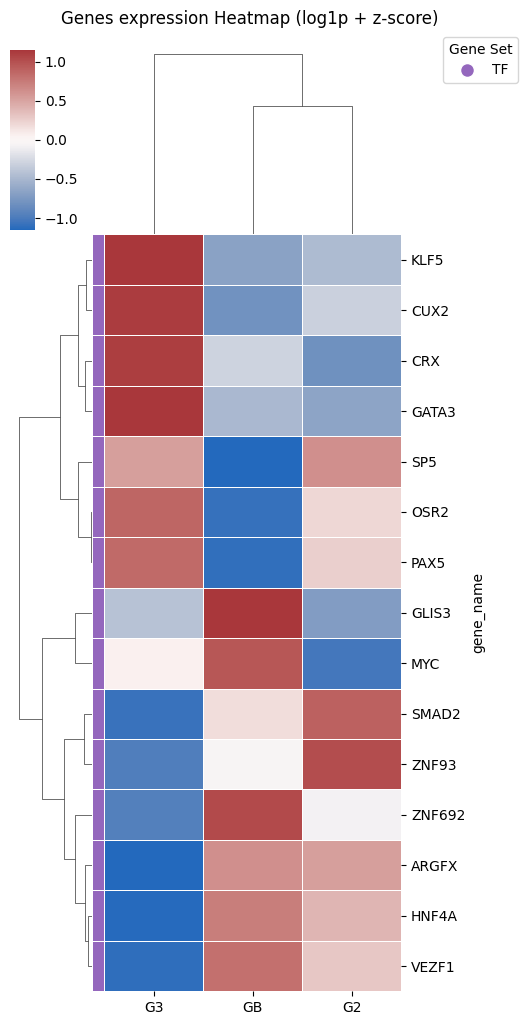

In [319]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 유전자 소속 정보 정의
gene_sets = {
    "TF" : ['CUX2','KLF5','FSC','CRX','GATA3','MYC','ZNF692','VEZF1','SP5','ZNF93','GLIS3','HNF4A','OSR2','SMAD2','ARGFX','PAX5']
}

# 유전자 → 집합 이름 매핑
gene_labels = {}
for label, genes in gene_sets.items():
    for g in genes:
        gene_labels[g] = label

# 유전자 리스트 (중복 제거)
selected_genes = list(gene_labels.keys())

# 1. log1p
df_log = df.copy()
df_log[['GB', 'G2', 'G3']] = np.log1p(df_log[['GB', 'G2', 'G3']])

# 2. 유전자 선택 및 row-wise z-score
df_sel = df_log[df_log['gene_name'].isin(selected_genes)].copy()
df_sel = df_sel.set_index('gene_name')
df_z = df_sel[['GB', 'G2', 'G3']].copy()
df_z = df_z.sub(df_z.mean(axis=1), axis=0).div(df_z.std(axis=1), axis=0)

# 3. 유전자 라벨 색상 매핑
label_colors = {
    "TF": "#9467bd"
}
row_colors = df_z.index.map(lambda g: label_colors[gene_labels[g]])

# 4. clustermap 그리기
g = sns.clustermap(df_z, 
                   cmap="vlag", 
                   center=0, 
                   linewidths=0.5, 
                   figsize=(5, 10),
                   method='average',
                   metric='euclidean',
                   row_colors=row_colors)

# 범례 추가
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
           for color in label_colors.values()]
labels = list(label_colors.keys())
g.fig.legend(handles, labels, title="Gene Set", loc="upper right", bbox_to_anchor=(1.05, 1))

plt.suptitle("Genes expression Heatmap (log1p + z-score)", y=1.02)
plt.show()


In [306]:
from gseapy import prerank
import pandas as pd
import numpy as np

# 1. log1p 처리
df_log = df.copy()
df_log[['GB', 'G2', 'G3']] = np.log1p(df[['GB', 'G2', 'G3']])

# 2. logFC 계산 (GB vs G2)
df_log['logFC_GB_G2'] = df_log['G3'] - df_log['G2']

# 3. 랭킹 파일 준비 (gene_name, logFC)
ranking = df_log[['gene_name', 'logFC_GB_G2']].dropna()
ranking.columns = ['gene', 'score']
ranking = ranking.sort_values('score', ascending=False)

# 4. GSEA preranked 실행
prerank_res = prerank(
    rnk=ranking,
    gene_sets='KEGG_2021_Human',  # 최신 KEGG 세트
    outdir=None,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    no_plot=True
)

# 5. 상위 Pathway 보기
pathway = prerank_res.res2d


2025-05-11 23:55:21,920 [WARNING] Duplicated values found in preranked stats: 48.04% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


/tmp/ipykernel_321470/3429078853.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered_pathways['FDR q-val'] = filtered_pathways['FDR q-val'].fillna(0)  # NaN을 0으로 대체
/tmp/ipykernel_321470/3429078853.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_pathways['FDR q-val'] = filtered_pathways['FDR q-val'].fillna(0)  # NaN을 0으로 대체
/tmp/ipykernel_321470/3429078853.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

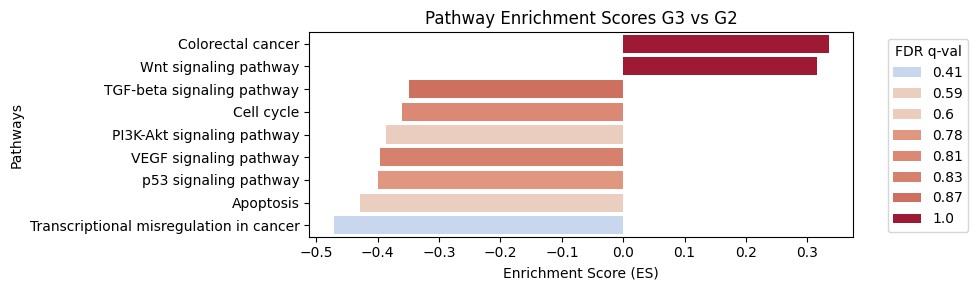

In [298]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

# 관심 있는 Pathway 리스트
pathways_of_interest = [
    'PI3K-Akt signaling pathway',
    'TGF-beta signaling pathway',
    'Wnt signaling pathway',
    'Cell cycle',
    'VEGF signaling pathway',
    'Apoptosis',
    'Colorectal cancer',
    'p53 signaling pathway',
    'Transcriptional misregulation in cancer'
]

# 1. Term 필터링
filtered_pathways = prerank_res.res2d[prerank_res.res2d['Term'].isin(pathways_of_interest)]

# 2. FDR 값에 NaN 체크 후 소수 둘째 자리 반올림
filtered_pathways['FDR q-val'] = filtered_pathways['FDR q-val'].fillna(0)  # NaN을 0으로 대체
filtered_pathways['FDR q-val'] = filtered_pathways['FDR q-val'].round(2)  # 소수 둘째 자리에서 반올림

# 3. FDR 값을 색상에 반영할 수 있도록 정규화
norm = mcolors.Normalize(vmin=0, vmax=1)  # 정규화 범위 설정 (0~1)
cmap = plt.cm.coolwarm  # 파랑 -> 빨강 색상 맵 (coolwarm은 연속적인 색상으로 파랑->빨강)

# 4. Bar plot 그리기
plt.figure(figsize=(10, 3))
sns.barplot(data=filtered_pathways.sort_values('ES', ascending=False), 
            x='ES', y='Term', 
            hue='FDR q-val', 
            palette=cmap(norm(filtered_pathways['FDR q-val'])),  # FDR 값으로 색상 적용
            dodge=False)

# 5. 범례 밖으로 이동
plt.legend(title='FDR q-val', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. 레이블 설정
plt.title('Pathway Enrichment Scores G3 vs G2')
plt.xlabel('Enrichment Score (ES)')
plt.ylabel('Pathways')
plt.tight_layout()

# 7. 출력
plt.show()


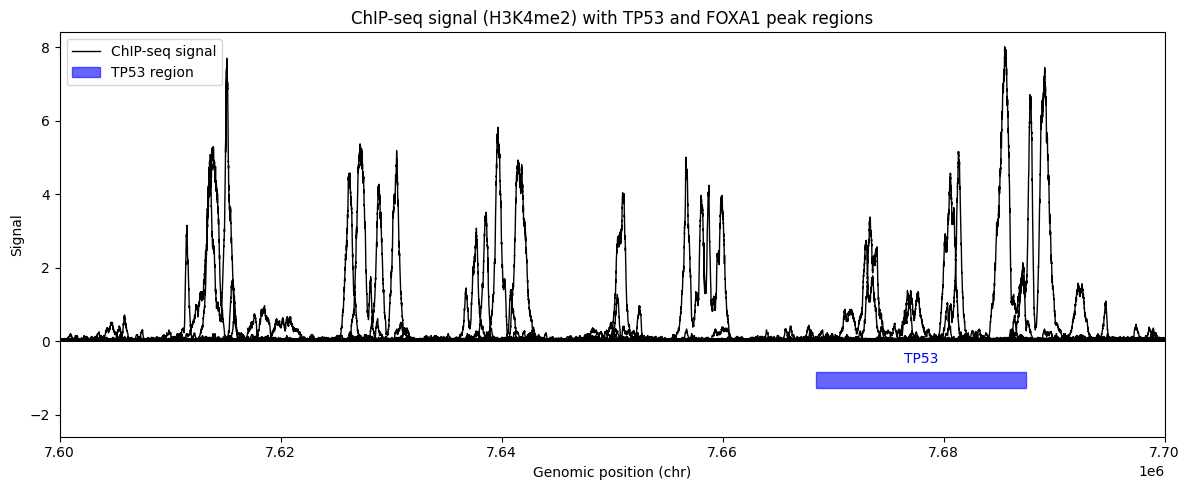

In [307]:
import pandas as pd
import matplotlib.pyplot as plt

# 파일 및 좌표 설정
file_path = "/home/Data_Drive_8TB/kykim/Mutect2/chipseq/GSM4149683_SW480_LSD1_EV_H3k4me2_ChIP_1.bedGraph"
plot_start = 7600000
plot_end = 7700000
tp53_start = 7668421
tp53_end = 7687490


# bedGraph 파일 로드
cols = ["chrom", "start", "end", "value"]
df = pd.read_csv(file_path, sep="\t", names=cols, comment="#", header=None)

# 관심 구간 필터링
df_region = df[(df["start"] < plot_end) & (df["end"] > plot_start)].copy()
df_region["mid"] = (df_region["start"] + df_region["end"]) // 2

# 그래프 그리기
plt.figure(figsize=(12, 5))
plt.plot(df_region["mid"], df_region["value"], color="black", linewidth=1, label="ChIP-seq signal")

# TP53 범위를 그래프 아래에 파란색 박스로 표시
y_min, y_max = plt.ylim()
box_y = y_min - (y_max - y_min) * 0.1  # y축 아래로 조금 내리기
box_height = (y_max - y_min) * 0.05

# TP53 박스
plt.gca().add_patch(plt.Rectangle(
    (tp53_start, box_y),                   # (x, y) 시작 좌표
    tp53_end - tp53_start,                # 너비
    box_height,                           # 높이
    color="blue", alpha=0.6, label="TP53 region"
))
plt.text((tp53_start + tp53_end)/2, box_y + box_height + 0.02 * (y_max - y_min),
         "TP53", color="blue", ha="center", va="bottom", fontsize=10)


# 축 설정
plt.xlim(plot_start, plot_end)
plt.ylim(foxa1_box_y - foxa1_box_height, y_max)
plt.xlabel("Genomic position (chr)")
plt.ylabel("Signal")
plt.title("ChIP-seq signal (H3K4me2) with TP53 and FOXA1 peak regions")
plt.legend()
plt.tight_layout()
plt.show()